In [54]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import pandas as pd
import seaborn as sns

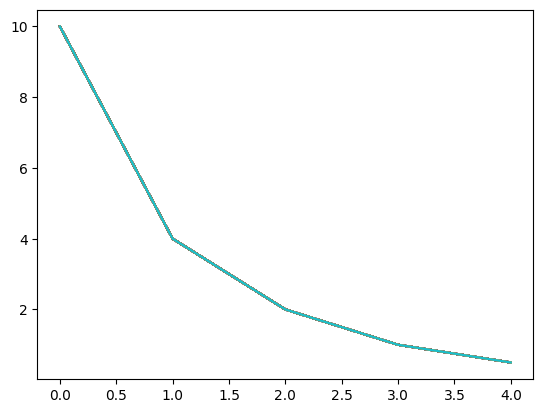

In [55]:
N_p = 100 # patients
N_t = 5 # time points (number of)
sc = 12 # scaling factor

y0 = np.zeros((N_p, N_t)) + np.array([10, 4, 2, 1, .5])

plt.plot(y0.T)
plt.show()

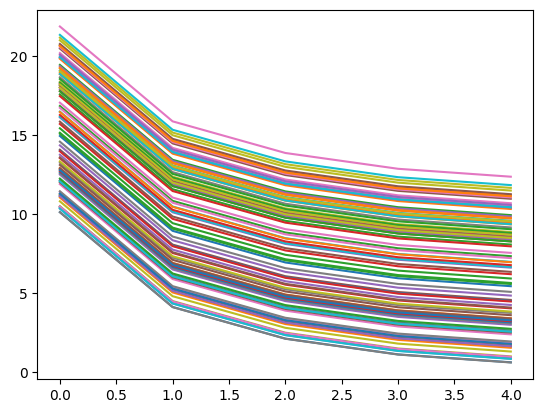

In [56]:
y_add = y0 + np.random.rand(N_p)[:, None] * sc

plt.plot(y_add.T)
plt.show()

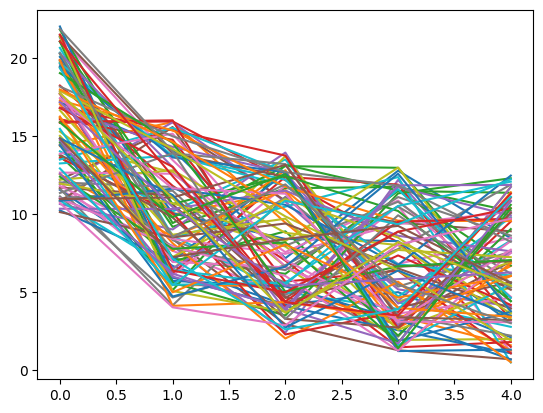

In [57]:
y_mult = y0 + np.random.rand(N_p, N_t) * sc

plt.plot(y_mult.T)
plt.show()

In [58]:
df_add = pd.DataFrame(data=y_add, columns=[f'T{i}' for i in range(N_t)])
df_add['Patient'] = np.arange(N_p) + 100
df_add = pd.melt(df_add, id_vars='Patient', value_vars=[f'T{i}' for i in range(N_t)], var_name='Week', value_name='y')

model = smf.mixedlm('y ~ Week', data=df_add, groups='Patient').fit()

model.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
=============================================================
Model:              MixedLM   Dependent Variable:   y        
No. Observations:   500       Method:               REML     
No. Groups:         100       Scale:                0.0000   
Min. group size:    5         Log-Likelihood:       3611.6826
Max. group size:    5         Converged:            Yes      
Mean group size:    5.0                                      
-------------------------------------------------------------
            Coef.   Std.Err.      z       P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept   15.656     0.159       98.228 0.000 15.344 15.968
Week[T.T1]  -6.000     0.000 -3232115.452 0.000 -6.000 -6.000
Week[T.T2]  -8.000     0.000 -4309487.270 0.000 -8.000 -8.000
Week[T.T3]  -9.000     0.000 -4848173.178 0.000 -9.000 -9.000
Week[T.T4]  -9.500     0.000 -5117516.133 0.000 -9.500 -9.500
Patient Var  2.540 13753.559                                 
=============================================================

"""

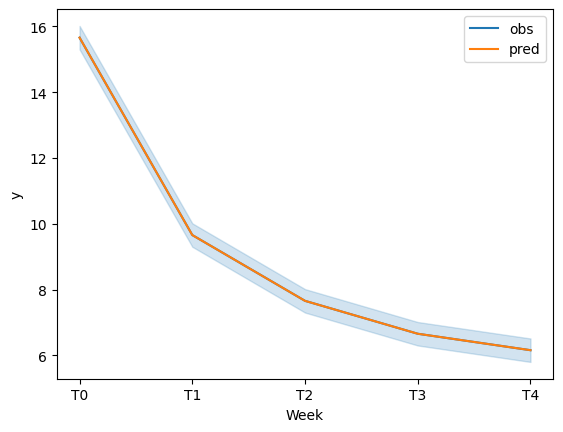

In [59]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()
b[1:] += b[0] 
sem[1:] += sem[0]
sns.lineplot(data=df_add, x='Week', y='y', errorbar='se', label= 'obs')
plt.plot(b, label = 'pred')
plt.legend()
plt.show()
#plt.fill_between(df_add.Week.unique(), b-sem, b+sem)

In [70]:
kill = np.random.randint(low=0, high=500, size=200)
df_add_kill = df_add.drop(index=kill)

model = smf.mixedlm('y ~ Week', data=df_add_kill, groups='Patient').fit()

model.summary()


<class 'statsmodels.iolib.summary2.Summary'>
"""
            Mixed Linear Model Regression Results
=============================================================
Model:              MixedLM   Dependent Variable:   y        
No. Observations:   331       Method:               REML     
No. Groups:         99        Scale:                0.0000   
Min. group size:    1         Log-Likelihood:       1798.0292
Max. group size:    5         Converged:            Yes      
Mean group size:    3.3                                      
-------------------------------------------------------------
            Coef.   Std.Err.      z       P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept   15.648     0.197       79.295 0.000 15.261 16.034
Week[T.T1]  -6.000     0.000 -1141417.483 0.000 -6.000 -6.000
Week[T.T2]  -8.000     0.000 -1561244.244 0.000 -8.000 -8.000
Week[T.T3]  -9.000     0.000 -1799452.772 0.000 -9.000 -9.000
Week[T.T4]  -9.500     0.000 -1922375.127 0.000 -9.500 -9.500
Patient Var  3.855 13090.279                                 
=============================================================

"""

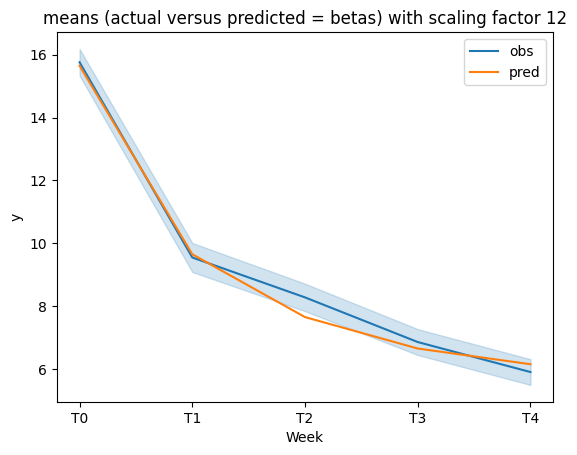

In [71]:
fe_params = model.fe_params.to_numpy()
bse = model.bse_fe.to_numpy()
b = fe_params.copy()
sem = bse.copy()
b[1:] += b[0] 
sem[1:] += sem[0]
sns.lineplot(data=df_add_kill, x='Week', y='y', errorbar='se', label = 'obs')
plt.plot(b,label = 'pred')

plt.legend()
plt.title(f"means (actual versus predicted = betas) with scaling factor {sc}")
plt.show()